In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:\\Users\\kendy\\OneDrive\\Desktop\\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Data Exploration

In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# Display sample data using head()

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Cleaning

In [7]:
#Removing Duplicates
print(df.duplicated().sum())

0


In [8]:
#removing null values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df=df.drop("Cabin", axis=1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [10]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [11]:
#removing outliers
a=df.select_dtypes(include=["int"])
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)
    IQR=q3-q1
    Uw=q3+1.5*IQR
    Lw=q1-1.5*IQR
    outliers=(a[i]>Uw)|(a[i]<Lw)
    print("before:",outliers.sum())
    a.loc[outliers,i]=q2
    print("after:",((a[i]>Uw)|(a[i]<Lw)).sum())

before: 0
after: 0
before: 0
after: 0
before: 0
after: 0
before: 46
after: 0
before: 213
after: 0


# Convert Columns

In [12]:
df["Age"] = df["Age"].astype(int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C


# Data Analysis

In [13]:
a=df.groupby("Survived")["Age"].mean().sort_values(ascending=False).head(5)
a

Survived
0    30.012750
1    28.274854
Name: Age, dtype: float64

### The average age of passengers who did not survive was 30.01 years.The average age of passengers who survived was 28.27 years.
This shows that survivors were slightly younger on average than non-survivors.

In [14]:
b=df.groupby("Pclass")["Fare"].mean().sort_values(ascending=False).head(5)
b

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

### 1-class passengers paid the highest average fare (84.15).2-class passengers paid an average fare of 20.66.3-class passengers paid the lowest average fare (13.68).
This shows that ticket fare decreases as passenger class decreases.

In [15]:
c=df.groupby("Sex")["Survived"].count().sort_values(ascending=False).head(5)
c

Sex
male      577
female    314
Name: Survived, dtype: int64

### There were 577 male passengers.There were 314 female passengers.
This shows that male passengers were more than female passengers

In [16]:
d=df.groupby("Embarked")["Fare"].count().sort_values(ascending=False).head(5)
d

Embarked
S    646
C    168
Q     77
Name: Fare, dtype: int64

### 646 passengers boarded at S.168 passengers boarded at C.77 passengers boarded at Q.
This shows that S was the most common embarked port.

In [17]:
e=df.groupby("Pclass")["Parch"].mean().sort_values(ascending=False).head(5)
e

Pclass
3    0.393075
2    0.380435
1    0.356481
Name: Parch, dtype: float64

### 3-class passengers had the highest average Parch (0.393).2-class passengers had an average of 0.380.1-class passengers had the lowest average (0.356).
This suggests that third-class passengers traveled with slightly more parents or children on average.

In [18]:
f=df.groupby("Sex")["Parch"].mean().sort_values(ascending=False).head(5)
f

Sex
female    0.649682
male      0.235702
Name: Parch, dtype: float64

### Female passengers had an average Parch of 0.649.Male passengers had an average Parch of 0.235.
This shows that female passengers were more likely to travel with parents or children than male passengers.

# Data Visualization

In [19]:
import seaborn as sns

In [20]:
import matplotlib.pyplot as plt

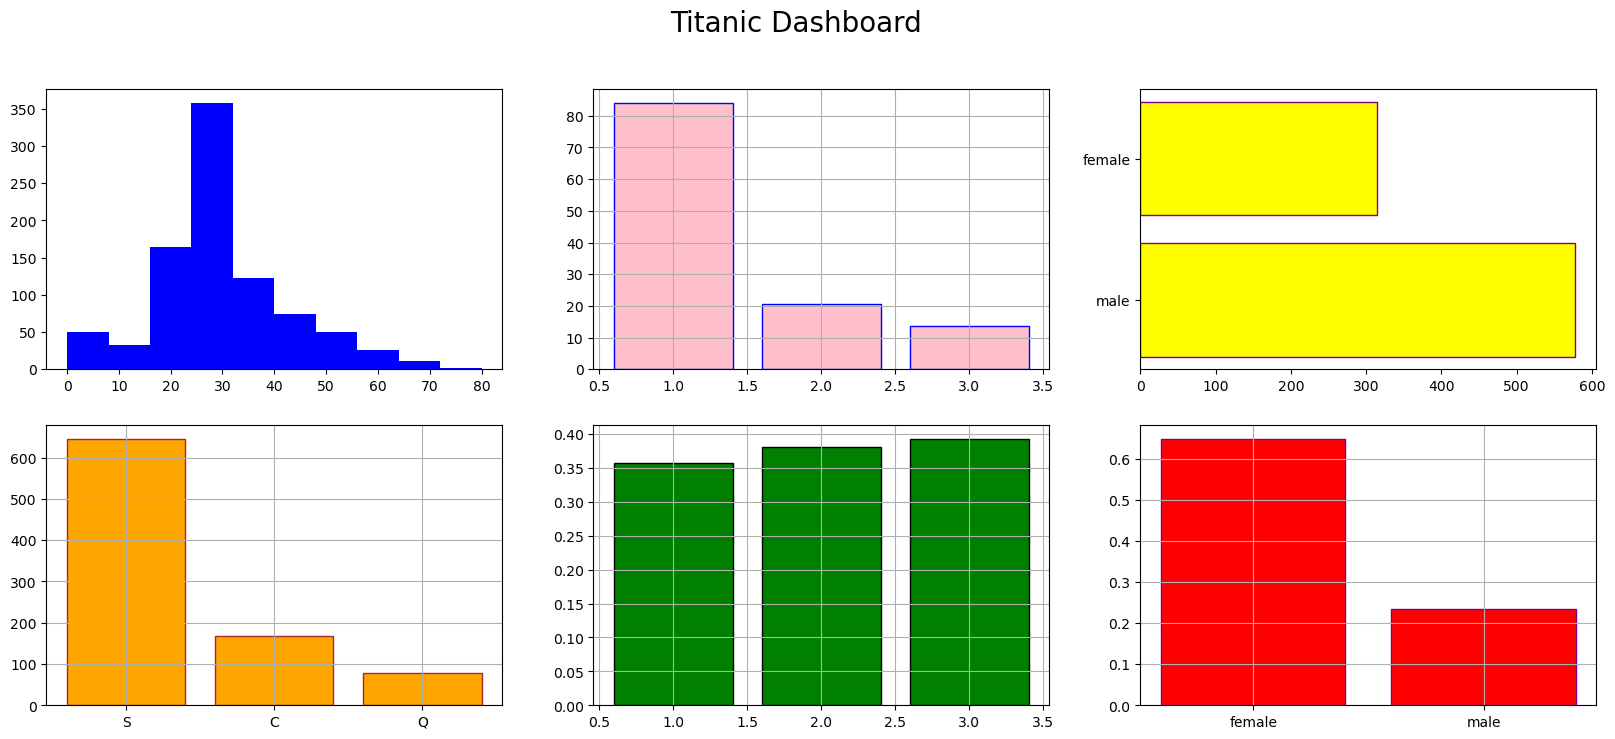

In [29]:
plt.figure(figsize=(20,8))
plt.suptitle("Titanic Dashboard",fontsize=20)
plt.subplot(2,3,1)
plt.hist(df["Age"],color="blue")
plt.subplot(2,3,2)
plt.bar(b.index,b.values,color="pink",edgecolor="blue")
plt.grid(True)
plt.subplot(2,3,3)
plt.barh(c.index,c.values,color="yellow",edgecolor="purple")
plt.subplot(2,3,4)
plt.bar(d.index,d.values,color="orange",edgecolor="brown")
plt.grid(True)
plt.subplot(2,3,5)
plt.bar(e.index,e.values,color="green",edgecolor="black")
plt.grid(True)
plt.subplot(2,3,6)
plt.bar(f.index,f.values,color="red",edgecolor="purple")
plt.grid(True)
plt.show()

# Summarize key findings and insights

In [28]:
#1.Survivors were sightly younger on average than non-survivors
#2.1-class passengers paid the highest average fare, while 3-class passengers paid the lowest
#3.The Dataset contained more male passengers than female passengers
#4.Most passengers boarded from S
#5.3-class passengers traveled with slightly more parents/children on average
#6.Female passengers traveled with more parents/children on average than male passengers